In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.figure_factory as ff

sns.set(style="whitegrid")
#Standardisation
from sklearn.preprocessing import StandardScaler
#ACP
from sklearn.decomposition import PCA
#CAH
from scipy.cluster.hierarchy import dendrogram, linkage
#K-means
from sklearn.cluster import KMeans

In [3]:
donnees_acp=pd.read_csv("..\data_clean\df_ACP.csv")
donnees_acp.head()

,Country,taux_remplissage,nb_colonnes_remplies,ISO3,indicateur_perf_logistique,pib_par_hab,stab_politique,population,tx_urbanisation,tarif_douanier_moyen,...,Producing Animals/Slaughtered,livestock_production,livestock_stock,livestock_yield_carcass_weight,poultry_price_lcu_t,poultry_export_t,poultry_import_t,cereal_production_t,cereal_import_t,cereal_export_t
0,Belgium,100.0,26,BEL,4.0,68157.834786,0.581982,11680210.0,98.153,1.95,...,297794.0,442020.00,53283.0,1484.0,1247.6,121147.0,109384.0,2352.0,9771.0,3460.0
1,Chile,100.0,26,CHL,3.0,30820.352697,0.132084,19553036.0,87.912,1.03,...,300523.0,692847.28,57142.0,2305.0,1090660.8,0.0,448.0,1715.0,4077.0,70.0
2,Canada,100.0,26,CAN,4.0,63578.320195,0.780682,38935934.0,81.752,1.83,...,789394.0,1370800.00,171099.0,1737.0,2893.9,4547.0,31890.0,48895.0,8213.0,22936.0
3,Bosnia and Herzegovina,100.0,26,BIH,3.0,21117.283077,-0.483194,3204802.0,49.841,3.39,...,43537.0,67007.00,9299.0,1539.0,2263.0,6641.0,29708.0,1268.0,773.0,100.0
4,Switzerland,100.0,26,CHE,4.1,91326.131705,1.159745,8777088.0,74.092,3.16,...,87825.0,109515.00,13109.0,1247.0,3527.0,1183.0,309.0,612.0,1606.0,184.0


In [4]:
donnees_acp.columns

Index(['Country', 'taux_remplissage', 'nb_colonnes_remplies', 'ISO3',
       'indicateur_perf_logistique', 'pib_par_hab', 'stab_politique',
       'population', 'tx_urbanisation', 'tarif_douanier_moyen',
       'emissions_agri_pc', 'organic_share', 'hfce_per_capita_usd_const2015',
       'food_balance_export_quantity', 'food_balance_import_quantity',
       'food_balance_production', 'Producing Animals/Slaughtered',
       'livestock_production', 'livestock_stock',
       'livestock_yield_carcass_weight', 'poultry_price_lcu_t',
       'poultry_export_t', 'poultry_import_t', 'cereal_production_t',
       'cereal_import_t', 'cereal_export_t'],
      dtype='object')

Sélection des colonnes quantitatives

In [5]:
# Sélection des colonnes quantitatives pour ACP
cols_acp = [
    'indicateur_perf_logistique',
    'pib_par_hab',
    'stab_politique',
    'population',
    'tx_urbanisation',
    'tarif_douanier_moyen',
    'emissions_agri_pc',
    'organic_share',
    'hfce_per_capita_usd_const2015',
    'food_balance_production',
    'Producing Animals/Slaughtered',
    'livestock_production',
    'livestock_stock',
    'livestock_yield_carcass_weight',
    'poultry_price_lcu_t',
    'poultry_export_t',
    'poultry_import_t',
    'cereal_production_t',
    'cereal_import_t',
    'cereal_export_t'
]

df_acp = donnees_acp[cols_acp].copy()
df_acp.head()

,indicateur_perf_logistique,pib_par_hab,stab_politique,population,tx_urbanisation,tarif_douanier_moyen,emissions_agri_pc,organic_share,hfce_per_capita_usd_const2015,food_balance_production,Producing Animals/Slaughtered,livestock_production,livestock_stock,livestock_yield_carcass_weight,poultry_price_lcu_t,poultry_export_t,poultry_import_t,cereal_production_t,cereal_import_t,cereal_export_t
0,4.0,68157.834786,0.581982,11680210.0,98.153,1.95,175.23042,7.49,21959.173610,450.0,297794.0,442020.00,53283.0,1484.0,1247.6,121147.0,109384.0,2352.0,9771.0,3460.0
1,3.0,30820.352697,0.132084,19553036.0,87.912,1.03,204.57184,1.76,9734.080367,769.0,300523.0,692847.28,57142.0,2305.0,1090660.8,0.0,448.0,1715.0,4077.0,70.0
2,4.0,63578.320195,0.780682,38935934.0,81.752,1.83,872.97530,2.75,26412.766573,1532.0,789394.0,1370800.00,171099.0,1737.0,2893.9,4547.0,31890.0,48895.0,8213.0,22936.0
3,3.0,21117.283077,-0.483194,3204802.0,49.841,3.39,234.02382,0.11,4506.032565,67.0,43537.0,67007.00,9299.0,1539.0,2263.0,6641.0,29708.0,1268.0,773.0,100.0
4,4.1,91326.131705,1.159745,8777088.0,74.092,3.16,143.30917,12.38,44877.858320,112.0,87825.0,109515.00,13109.0,1247.0,3527.0,1183.0,309.0,612.0,1606.0,184.0


Regarder les valeurs manquantes

In [6]:
df_acp.isna().sum()


indicateur_perf_logistique        29
pib_par_hab                        1
stab_politique                     0
population                         0
tx_urbanisation                    0
tarif_douanier_moyen              28
emissions_agri_pc                  1
organic_share                     21
hfce_per_capita_usd_const2015     20
food_balance_production            0
Producing Animals/Slaughtered      3
livestock_production               1
livestock_stock                   11
livestock_yield_carcass_weight     4
poultry_price_lcu_t               29
poultry_export_t                  58
poultry_import_t                   5
cereal_production_t                0
cereal_import_t                    0
cereal_export_t                    0
dtype: int64

Exclusions des colonnes avec trop de valeurs manquantes

In [7]:
# Liste des colonnes à exclure pour l’ACP
cols_exclude_missing = [
    "indicateur_perf_logistique",
    "organic_share",
    "hfce_per_capita_usd_const2015",
    "poultry_price_lcu_t",
    "poultry_export_t",
    "livestock_stock",
    "tarif_douanier_moyen"
]

df_acp=df_acp.drop(columns=cols_exclude_missing)
df_acp.head()

,pib_par_hab,stab_politique,population,tx_urbanisation,emissions_agri_pc,food_balance_production,Producing Animals/Slaughtered,livestock_production,livestock_yield_carcass_weight,poultry_import_t,cereal_production_t,cereal_import_t,cereal_export_t
0,68157.834786,0.581982,11680210.0,98.153,175.23042,450.0,297794.0,442020.00,1484.0,109384.0,2352.0,9771.0,3460.0
1,30820.352697,0.132084,19553036.0,87.912,204.57184,769.0,300523.0,692847.28,2305.0,448.0,1715.0,4077.0,70.0
2,63578.320195,0.780682,38935934.0,81.752,872.97530,1532.0,789394.0,1370800.00,1737.0,31890.0,48895.0,8213.0,22936.0
3,21117.283077,-0.483194,3204802.0,49.841,234.02382,67.0,43537.0,67007.00,1539.0,29708.0,1268.0,773.0,100.0
4,91326.131705,1.159745,8777088.0,74.092,143.30917,112.0,87825.0,109515.00,1247.0,309.0,612.0,1606.0,184.0


In [8]:
# Vérifier les manquants restants
df_acp.isna().sum()

pib_par_hab                       1
stab_politique                    0
population                        0
tx_urbanisation                   0
emissions_agri_pc                 1
food_balance_production           0
Producing Animals/Slaughtered     3
livestock_production              1
livestock_yield_carcass_weight    4
poultry_import_t                  5
cereal_production_t               0
cereal_import_t                   0
cereal_export_t                   0
dtype: int64

Correction des colonnes avec peu de valeurs manquantes par la médiane

In [9]:
#Imputation par la médiane
df_acp = df_acp.fillna(df_acp.median())
df_acp.isna().sum()

pib_par_hab                       0
stab_politique                    0
population                        0
tx_urbanisation                   0
emissions_agri_pc                 0
food_balance_production           0
Producing Animals/Slaughtered     0
livestock_production              0
livestock_yield_carcass_weight    0
poultry_import_t                  0
cereal_production_t               0
cereal_import_t                   0
cereal_export_t                   0
dtype: int64

In [10]:
df_acp.describe().T

,count,mean,std,min,25%,50%,75%,max
pib_par_hab,154.0,2.834308e+04,2.771247e+04,1484.241169,7.494521e+03,1.803527e+04,4.215332e+04,1.433819e+05
stab_politique,154.0,-1.025302e-01,8.967140e-01,-2.776898,-6.262256e-01,-7.032265e-02,6.436555e-01,1.321169e+00
population,154.0,4.906507e+07,1.661936e+08,92840.000000,3.251330e+06,1.045038e+07,3.546101e+07,1.425423e+09
tx_urbanisation,154.0,6.176316e+01,2.182965e+01,16.894000,4.591975e+01,6.368600e+01,8.106425e+01,1.000000e+02
emissions_agri_pc,154.0,3.593030e+02,4.824771e+02,12.802868,1.384086e+02,2.150806e+02,3.499192e+02,3.833415e+03
food_balance_production,154.0,8.930130e+02,3.014883e+03,0.000000,2.150000e+01,1.170000e+02,4.970000e+02,2.523500e+04
Producing Animals/Slaughtered,154.0,4.770454e+05,1.403512e+06,0.000000,1.503925e+04,8.072800e+04,2.947738e+05,1.180265e+07
livestock_production,154.0,7.848015e+05,2.410259e+06,0.000000,1.974434e+04,1.182250e+05,4.670925e+05,1.984124e+07
livestock_yield_carcass_weight,154.0,1.463065e+03,5.596342e+02,550.000000,1.020250e+03,1.473000e+03,1.746000e+03,3.688000e+03
poultry_import_t,154.0,1.051372e+04,4.304174e+04,0.000000,1.507500e+02,8.680000e+02,3.917500e+03,4.705330e+05


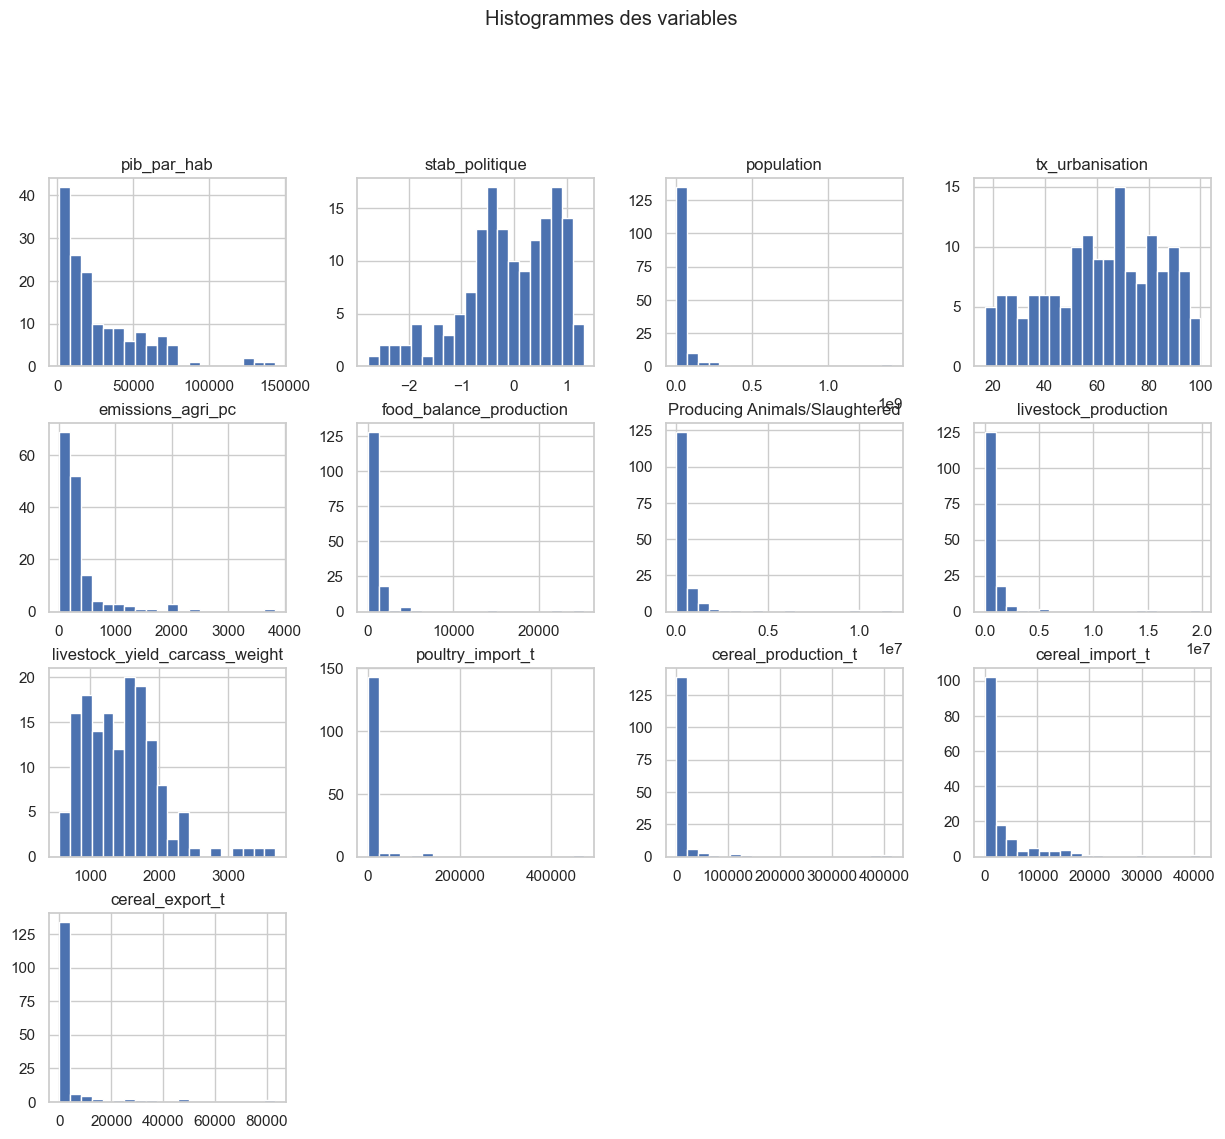

In [11]:
df_acp.hist(figsize=(15,12), bins=20)
plt.suptitle("Histogrammes des variables", y=1.02)
plt.show()


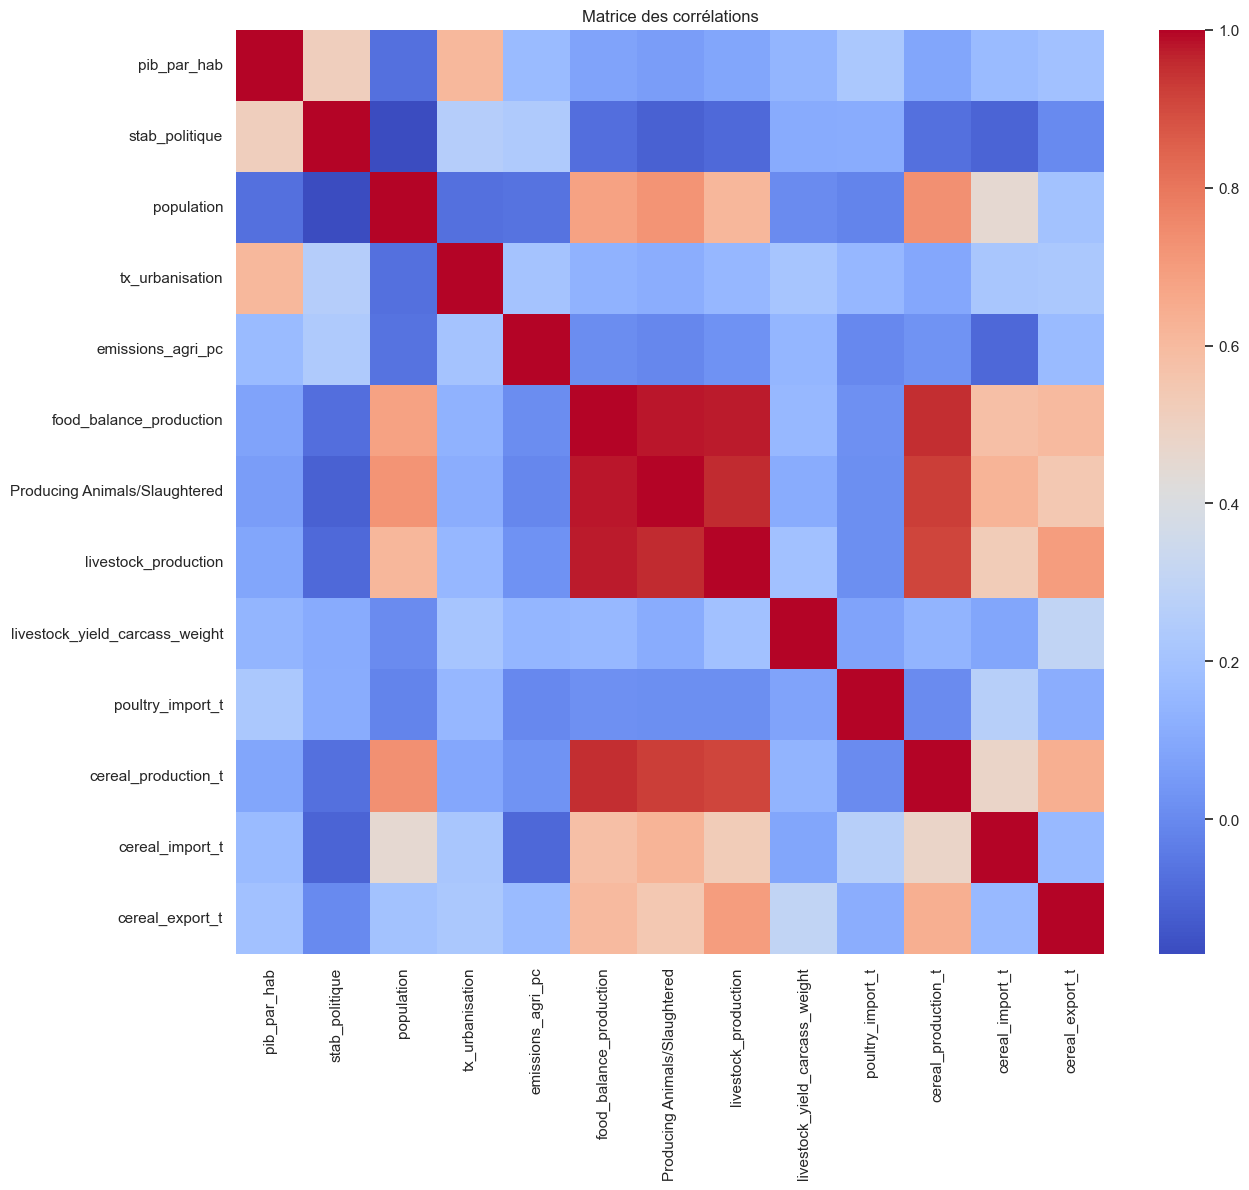

In [12]:
plt.figure(figsize=(14,12))
sns.heatmap(df_acp.corr(), cmap="coolwarm", annot=False)
plt.title("Matrice des corrélations")
plt.show()


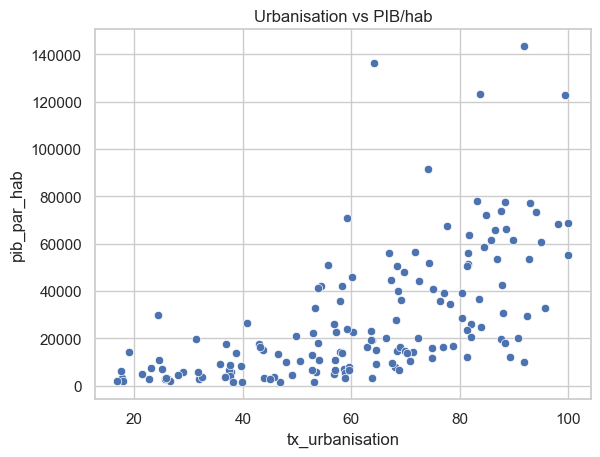

In [13]:
sns.scatterplot(data=df_acp, x="tx_urbanisation", y="pib_par_hab")
plt.title("Urbanisation vs PIB/hab")
plt.show()


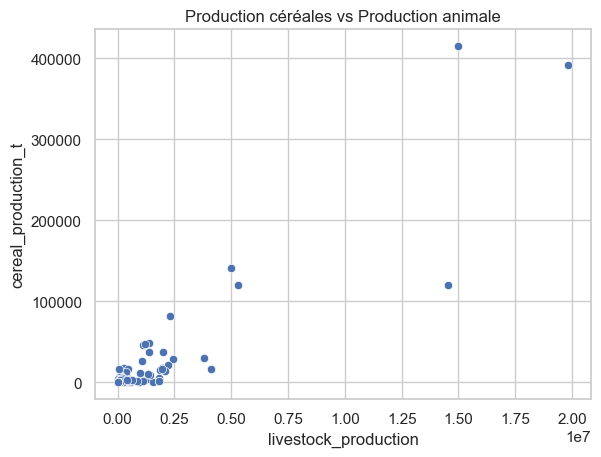

In [14]:
sns.scatterplot(data=df_acp, x="livestock_production", y="cereal_production_t")
plt.title("Production céréales vs Production animale")
plt.show()


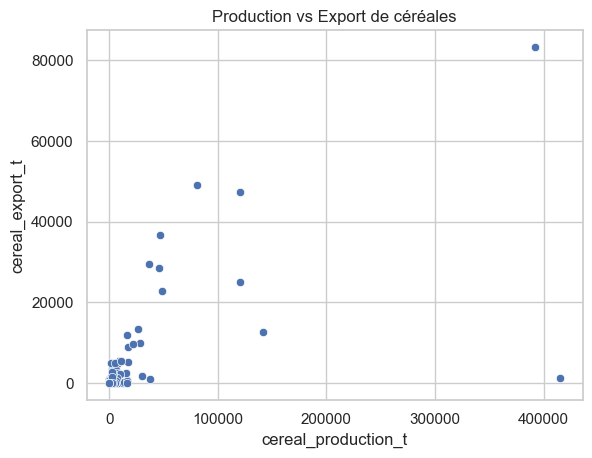

In [15]:
sns.scatterplot(data=df_acp, x="cereal_production_t", y="cereal_export_t")
plt.title("Production vs Export de céréales")
plt.show()


# Réduire la taille d'effet

In [16]:
df_acp.head()

,pib_par_hab,stab_politique,population,tx_urbanisation,emissions_agri_pc,food_balance_production,Producing Animals/Slaughtered,livestock_production,livestock_yield_carcass_weight,poultry_import_t,cereal_production_t,cereal_import_t,cereal_export_t
0,68157.834786,0.581982,11680210.0,98.153,175.23042,450.0,297794.0,442020.00,1484.0,109384.0,2352.0,9771.0,3460.0
1,30820.352697,0.132084,19553036.0,87.912,204.57184,769.0,300523.0,692847.28,2305.0,448.0,1715.0,4077.0,70.0
2,63578.320195,0.780682,38935934.0,81.752,872.97530,1532.0,789394.0,1370800.00,1737.0,31890.0,48895.0,8213.0,22936.0
3,21117.283077,-0.483194,3204802.0,49.841,234.02382,67.0,43537.0,67007.00,1539.0,29708.0,1268.0,773.0,100.0
4,91326.131705,1.159745,8777088.0,74.092,143.30917,112.0,87825.0,109515.00,1247.0,309.0,612.0,1606.0,184.0


Création des features engineering

In [17]:
variables_a_normaliser = [
    "cereal_production_t",
    "livestock_production",
    "Producing Animals/Slaughtered",
    "food_balance_production",
    "cereal_import_t",
    "cereal_export_t",
    "poultry_import_t"
]

for var in variables_a_normaliser:
    df_acp[var + "_per_capita"] = np.log1p(df_acp[var]) - np.log1p(df_acp["population"])


In [18]:
corr_pop = df_acp.corr()["population"].sort_values(ascending=False)
print(corr_pop)

population                                  1.000000
cereal_production_t                         0.732462
Producing Animals/Slaughtered               0.724991
food_balance_production                     0.682177
livestock_production                        0.612471
cereal_import_t                             0.454622
cereal_export_t                             0.198329
cereal_production_t_per_capita              0.134351
livestock_yield_carcass_weight              0.008042
livestock_production_per_capita             0.003706
Producing Animals/Slaughtered_per_capita   -0.004310
food_balance_production_per_capita         -0.010951
poultry_import_t                           -0.018352
emissions_agri_pc                          -0.063622
tx_urbanisation                            -0.069605
pib_par_hab                                -0.070855
cereal_export_t_per_capita                 -0.075114
stab_politique                             -0.170104
poultry_import_t_per_capita                -0.

In [19]:
vars_to_remove = [
    "cereal_production_t",
    "livestock_production",
    "Producing Animals/Slaughtered",
    "food_balance_production",
    "cereal_import_t",
    "cereal_export_t",
    "poultry_import_t"
]

df_acp = df_acp.drop(columns=vars_to_remove)
df_acp.head()

,pib_par_hab,stab_politique,population,tx_urbanisation,emissions_agri_pc,livestock_yield_carcass_weight,cereal_production_t_per_capita,livestock_production_per_capita,Producing Animals/Slaughtered_per_capita,food_balance_production_per_capita,cereal_import_t_per_capita,cereal_export_t_per_capita,poultry_import_t_per_capita
0,68157.834786,0.581982,11680210.0,98.153,175.23042,1484.0,-8.509960,-3.274294,-3.669246,-10.161939,-7.086130,-8.124094,-4.670778
1,30820.352697,0.132084,19553036.0,87.912,204.57184,2305.0,-9.340890,-3.340075,-4.175358,-10.142251,-8.475279,-12.525961,-10.681618
2,63578.320195,0.780682,38935934.0,81.752,872.97530,1737.0,-6.679977,-3.346522,-3.898406,-10.142446,-8.463833,-7.436922,-7.107349
3,21117.283077,-0.483194,3204802.0,49.841,234.02382,1539.0,-7.834177,-3.867594,-4.298772,-10.760653,-8.328589,-10.365041,-4.680956
4,91326.131705,1.159745,8777088.0,74.092,143.30917,1247.0,-9.569290,-4.383829,-4.604542,-11.260268,-8.605531,-10.767300,-10.251083


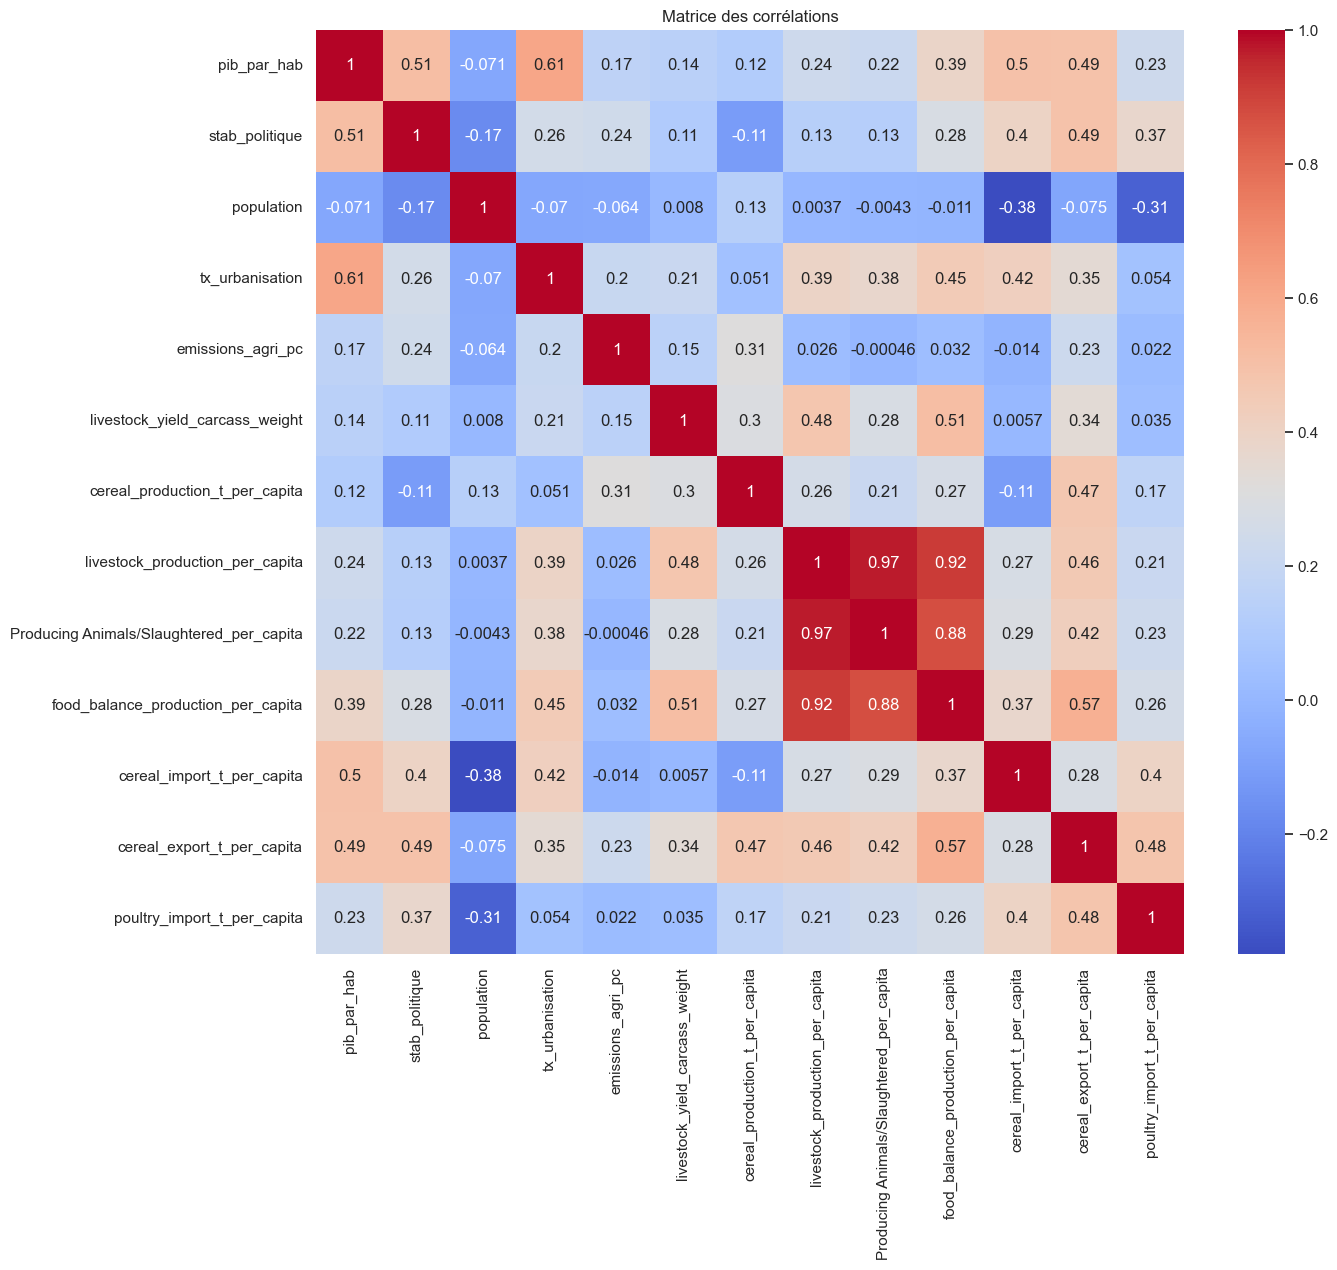

In [20]:
plt.figure(figsize=(14,12))
sns.heatmap(df_acp.corr(), cmap="coolwarm", annot=True)
plt.title("Matrice des corrélations")
plt.show()


In [21]:
#Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_acp)

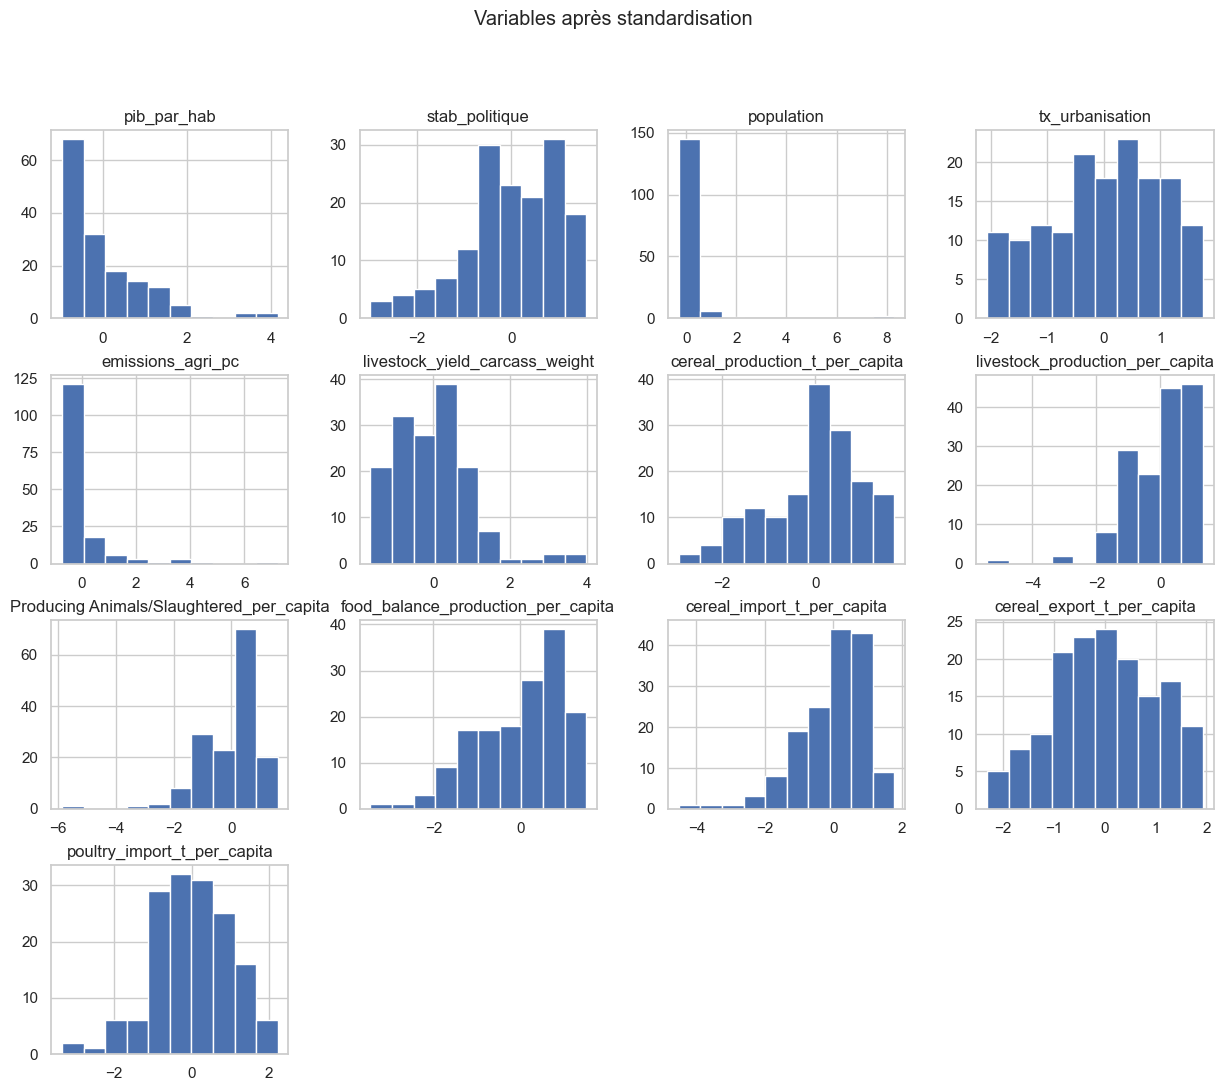

In [22]:
df_scaled = pd.DataFrame(X_scaled, columns=df_acp.columns)
df_scaled.hist(figsize=(15,12))
plt.suptitle("Variables après standardisation")
plt.show()


### Gestion des valeurs extrêmes (outliers)

Les variables agricoles, commerciales et démographiques présentent naturellement des distributions très asymétriques,
avec des valeurs extrêmes correspondant à des pays fortement spécialisés ou de grande taille.
Ces valeurs ne constituent pas des erreurs de mesure, mais reflètent des réalités économiques et structurelles.

Afin de conserver l’information portée par ces observations tout en évitant qu’elles ne dominent l’Analyse en Composantes
Principales (ACP), les choix méthodologiques suivants ont été effectués :

- Normalisation des variables de volume par la population afin de travailler sur des indicateurs d’intensité (per capita) ;
- Transformation logarithmique des variables avant normalisation par la population 
  (`log(1 + variable) - log(1 + population)`), permettant de réduire l’asymétrie des distributions
  tout en conservant les écarts relatifs entre pays ;
- Standardisation des variables (centrage-réduction) avant l’ACP.

Ainsi, les valeurs extrêmes sont conservées car elles sont économiquement pertinentes,
mais leur influence est contrôlée. Les distributions obtenues après transformation sont plus équilibrées,
ce qui permet une ACP plus stable et interprétable, sans suppression arbitraire d’observations.


In [23]:
#ACP
pca = PCA()  # deux axes principaux
# pca = PCA()
X_pca = pca.fit_transform(X_scaled)
pca.explained_variance_ratio_

array([0.35374152, 0.15476667, 0.1143776 , 0.09296816, 0.06885176,
       0.05906335, 0.05278736, 0.03188931, 0.02924445, 0.02079828,
       0.01535289, 0.00578855, 0.00037009])

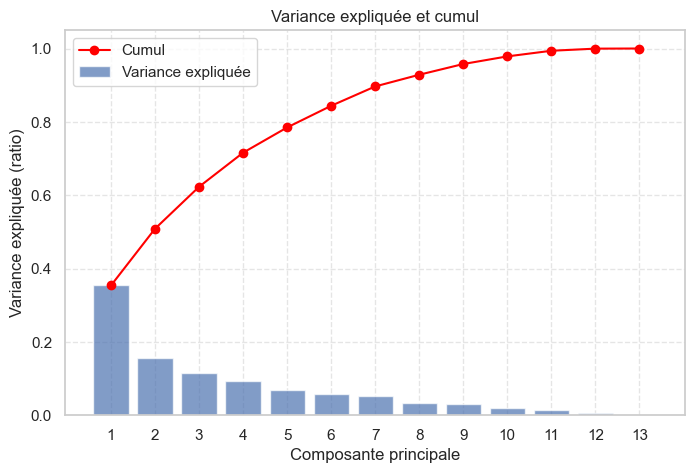

In [24]:
# Variance expliquée par composante
var_exp = pca.explained_variance_ratio_

# Cumul en pourcentage
cum_exp = np.cumsum(var_exp)

plt.figure(figsize=(8,5))

# Barres
plt.bar(range(1, len(var_exp)+1), var_exp, alpha=0.7, label="Variance expliquée")

# Ligne rouge du cumul
plt.plot(range(1, len(cum_exp)+1), cum_exp, marker='o', color='red', label="Cumul")

plt.xlabel("Composante principale")
plt.ylabel("Variance expliquée (ratio)")
plt.title("Variance expliquée et cumul")
plt.xticks(range(1, len(var_exp)+1))  # pour afficher tous les indices
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.show()


In [25]:
# Colonnes numériques réellement utilisées dans l'ACP
cols_acp = df_acp.columns.tolist()

print("Colonnes ACP retenues :", cols_acp)
print("Nombre :", len(cols_acp))

Colonnes ACP retenues : ['pib_par_hab', 'stab_politique', 'population', 'tx_urbanisation', 'emissions_agri_pc', 'livestock_yield_carcass_weight', 'cereal_production_t_per_capita', 'livestock_production_per_capita', 'Producing Animals/Slaughtered_per_capita', 'food_balance_production_per_capita', 'cereal_import_t_per_capita', 'cereal_export_t_per_capita', 'poultry_import_t_per_capita']
Nombre : 13


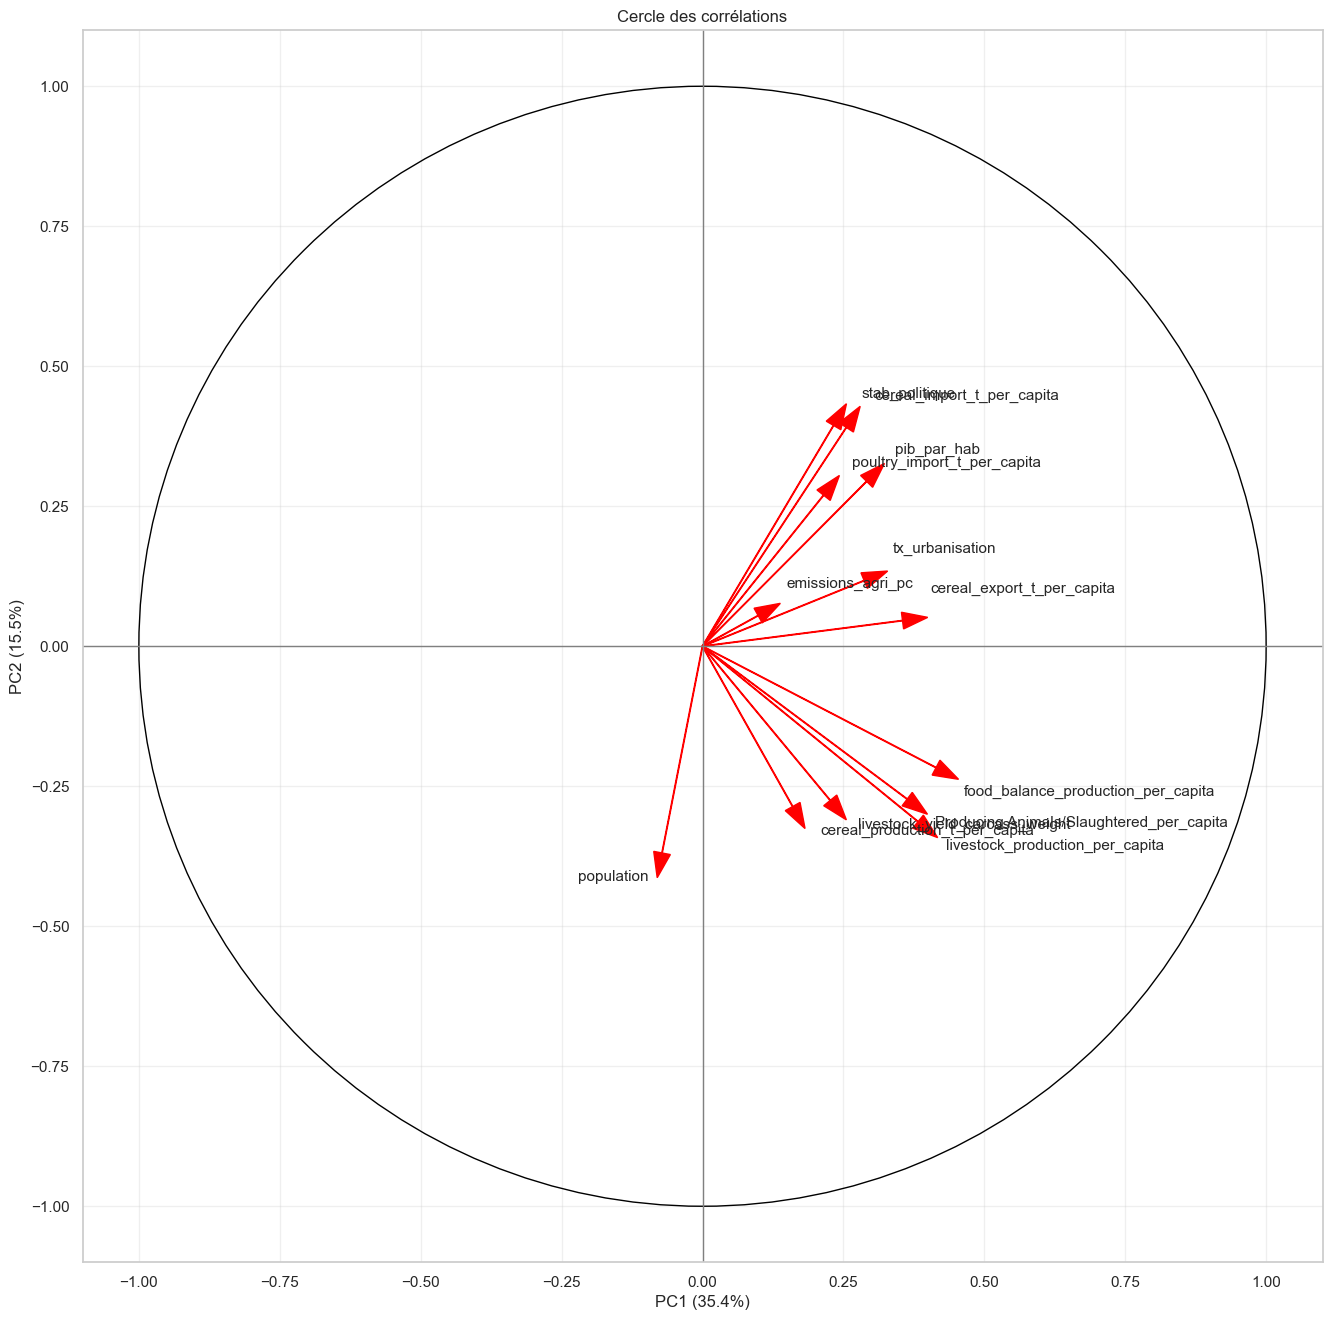

In [26]:
plt.figure(figsize=(16,16))

# Cercle unité
circle = plt.Circle((0,0), 1, color='black', fill=False, linewidth=1)
plt.gca().add_artist(circle)

for i, col in enumerate(cols_acp):
    x = pca.components_[0, i]
    y = pca.components_[1, i]
    
    # Flèche
    plt.arrow(0, 0, x, y, head_width=0.03, color='red')
    
    # Décalage dynamique : 
    # à droite → texte à droite, 
    # à gauche → texte à gauche, etc.
    dx = 0.05 if x >= 0 else -0.15
    dy = 0.05 if y >= 0 else -0.05
    
    plt.text(x + dx, y + dy, col, fontsize=11)

plt.axhline(0, color='grey', linewidth=1)
plt.axvline(0, color='grey', linewidth=1)

plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("Cercle des corrélations")
plt.grid(alpha=0.3)
plt.show()


In [27]:
# Loadings PC1 et PC2
pc1 = pca.components_[0]
pc2 = pca.components_[1]

threshold = 0.3  # seuil que tu peux ajuster

important_vars = []

for i, col in enumerate(cols_acp):
    if abs(pc1[i]) > threshold or abs(pc2[i]) > threshold:
        important_vars.append({
            "Variable": col,
            "PC1_loading": pc1[i],
            "PC2_loading": pc2[i]
        })

df_imp = pd.DataFrame(important_vars).sort_values(
    by=["PC1_loading", "PC2_loading"], 
    key=np.abs, 
    ascending=False
)

print(df_imp)

                                   Variable  PC1_loading  PC2_loading
4        food_balance_production_per_capita     0.414362    -0.216741
2           livestock_production_per_capita     0.382394    -0.313206
3  Producing Animals/Slaughtered_per_capita     0.363145    -0.272961
6                cereal_export_t_per_capita     0.354880     0.045812
5                cereal_import_t_per_capita     0.255178     0.390762
0                            stab_politique     0.232524     0.394296
1                                population    -0.071763    -0.369154


In [28]:
donnees_acp["PC1"]=X_pca[:,0]
donnees_acp["PC2"]=X_pca[:,1]

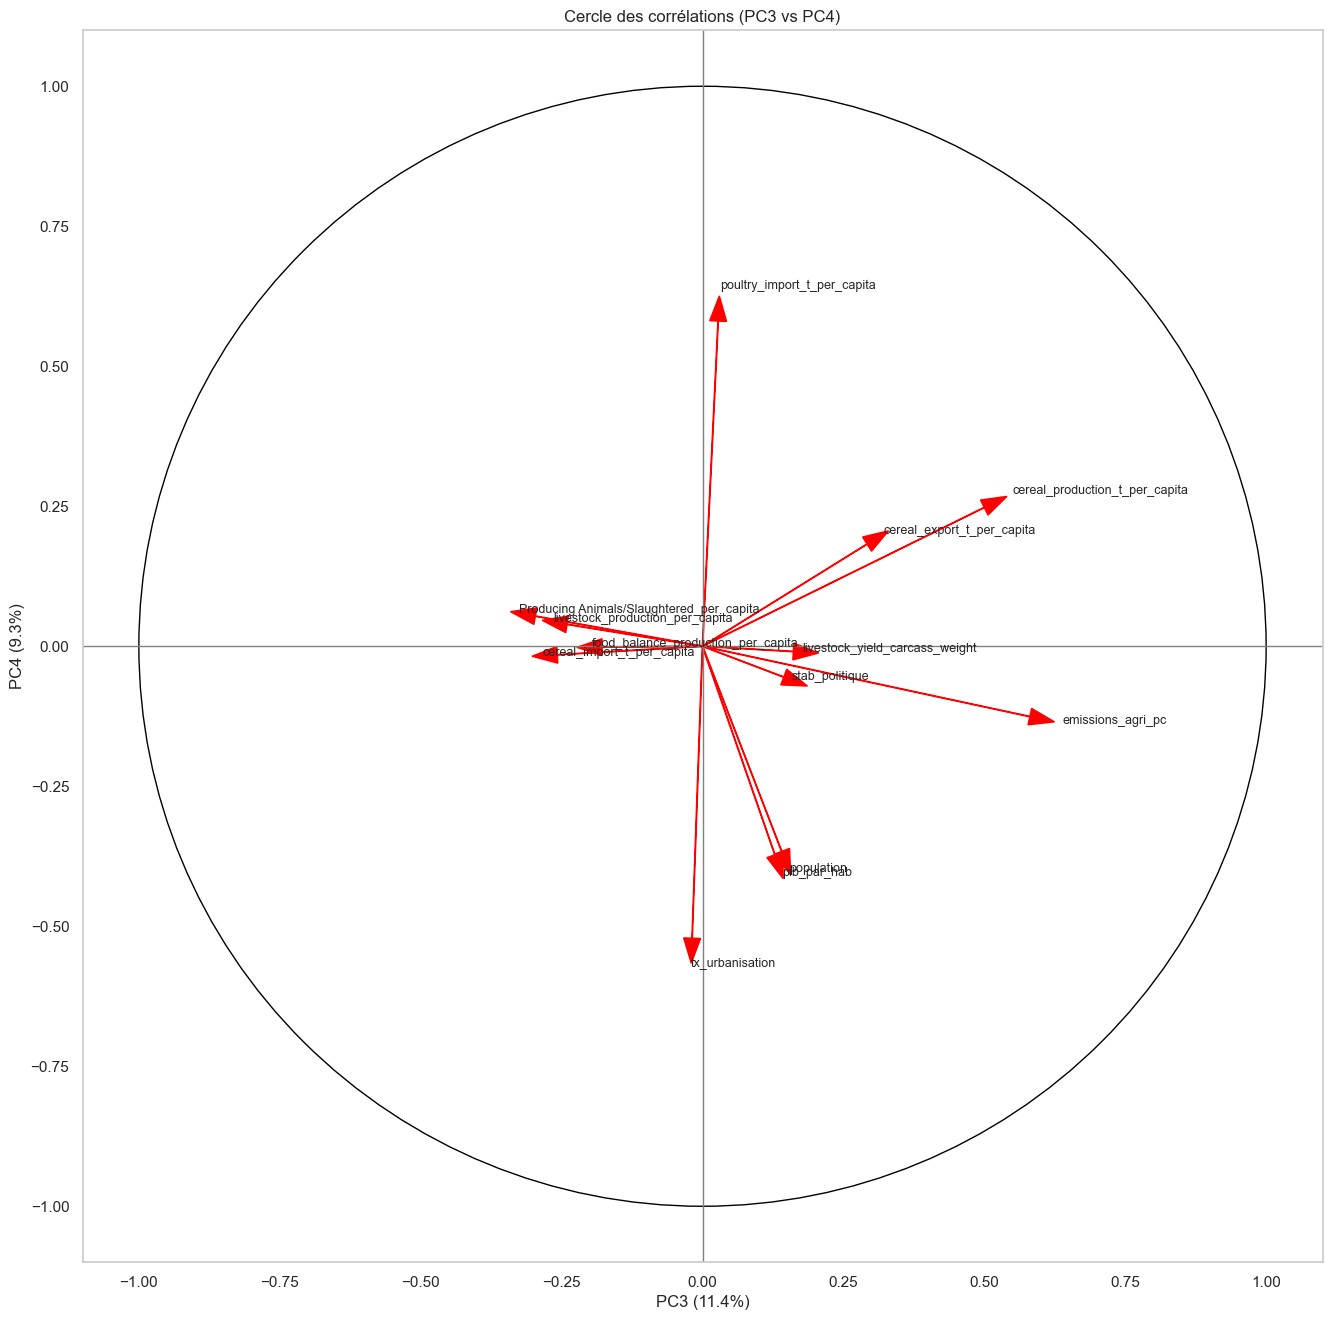

In [29]:
plt.figure(figsize=(16,16))

# Cercle unité
circle = plt.Circle((0,0), 1, color='black', fill=False, linewidth=1)
plt.gca().add_artist(circle)

# Vecteurs variables (PC3 = composante 2, PC4 = composante 3)
for i, col in enumerate(cols_acp):
    plt.arrow(0, 0, 
              pca.components_[2, i],   # PC3
              pca.components_[3, i],   # PC4
              head_width=0.03, 
              color='red')
    plt.text(pca.components_[2, i]*1.1, 
             pca.components_[3, i]*1.1, 
             col, fontsize=9)

# Axes
plt.axhline(0, color='grey', linewidth=1)
plt.axvline(0, color='grey', linewidth=1)

plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)

plt.xlabel("PC3 (%.1f%%)" % (pca.explained_variance_ratio_[2]*100))
plt.ylabel("PC4 (%.1f%%)" % (pca.explained_variance_ratio_[3]*100))

plt.title("Cercle des corrélations (PC3 vs PC4)")
plt.grid()
plt.show()

In [30]:
# Loadings PC3 et PC4
pc3 = pca.components_[2]
pc4 = pca.components_[3]

threshold = 0.35  # seuil recommandé car PC3 & PC4 ont des valeurs plus petites

important_vars_pc3_pc4 = []

for i, col in enumerate(cols_acp):
    if abs(pc3[i]) > threshold or abs(pc4[i]) > threshold:
        important_vars_pc3_pc4.append({
            "Variable": col,
            "PC3_loading": pc3[i],
            "PC4_loading": pc4[i]
        })

df_imp34 = pd.DataFrame(important_vars_pc3_pc4).sort_values(
    by=["PC3_loading", "PC4_loading"],
    key=np.abs,
    ascending=False
)

print("\n===== VARIABLES IMPORTANTES PC3–PC4 =====")
print(df_imp34)


===== VARIABLES IMPORTANTES PC3–PC4 =====
                         Variable  PC3_loading  PC4_loading
3               emissions_agri_pc     0.580672    -0.125571
4  cereal_production_t_per_capita     0.499906     0.247687
1                      population     0.140422    -0.366301
0                     pib_par_hab     0.128476    -0.372514
5     poultry_import_t_per_capita     0.027751     0.580662
2                 tx_urbanisation    -0.018390    -0.521280


In [31]:
donnees_acp["PC3"]=X_pca[:,2]
donnees_acp["PC4"]=X_pca[:,3]

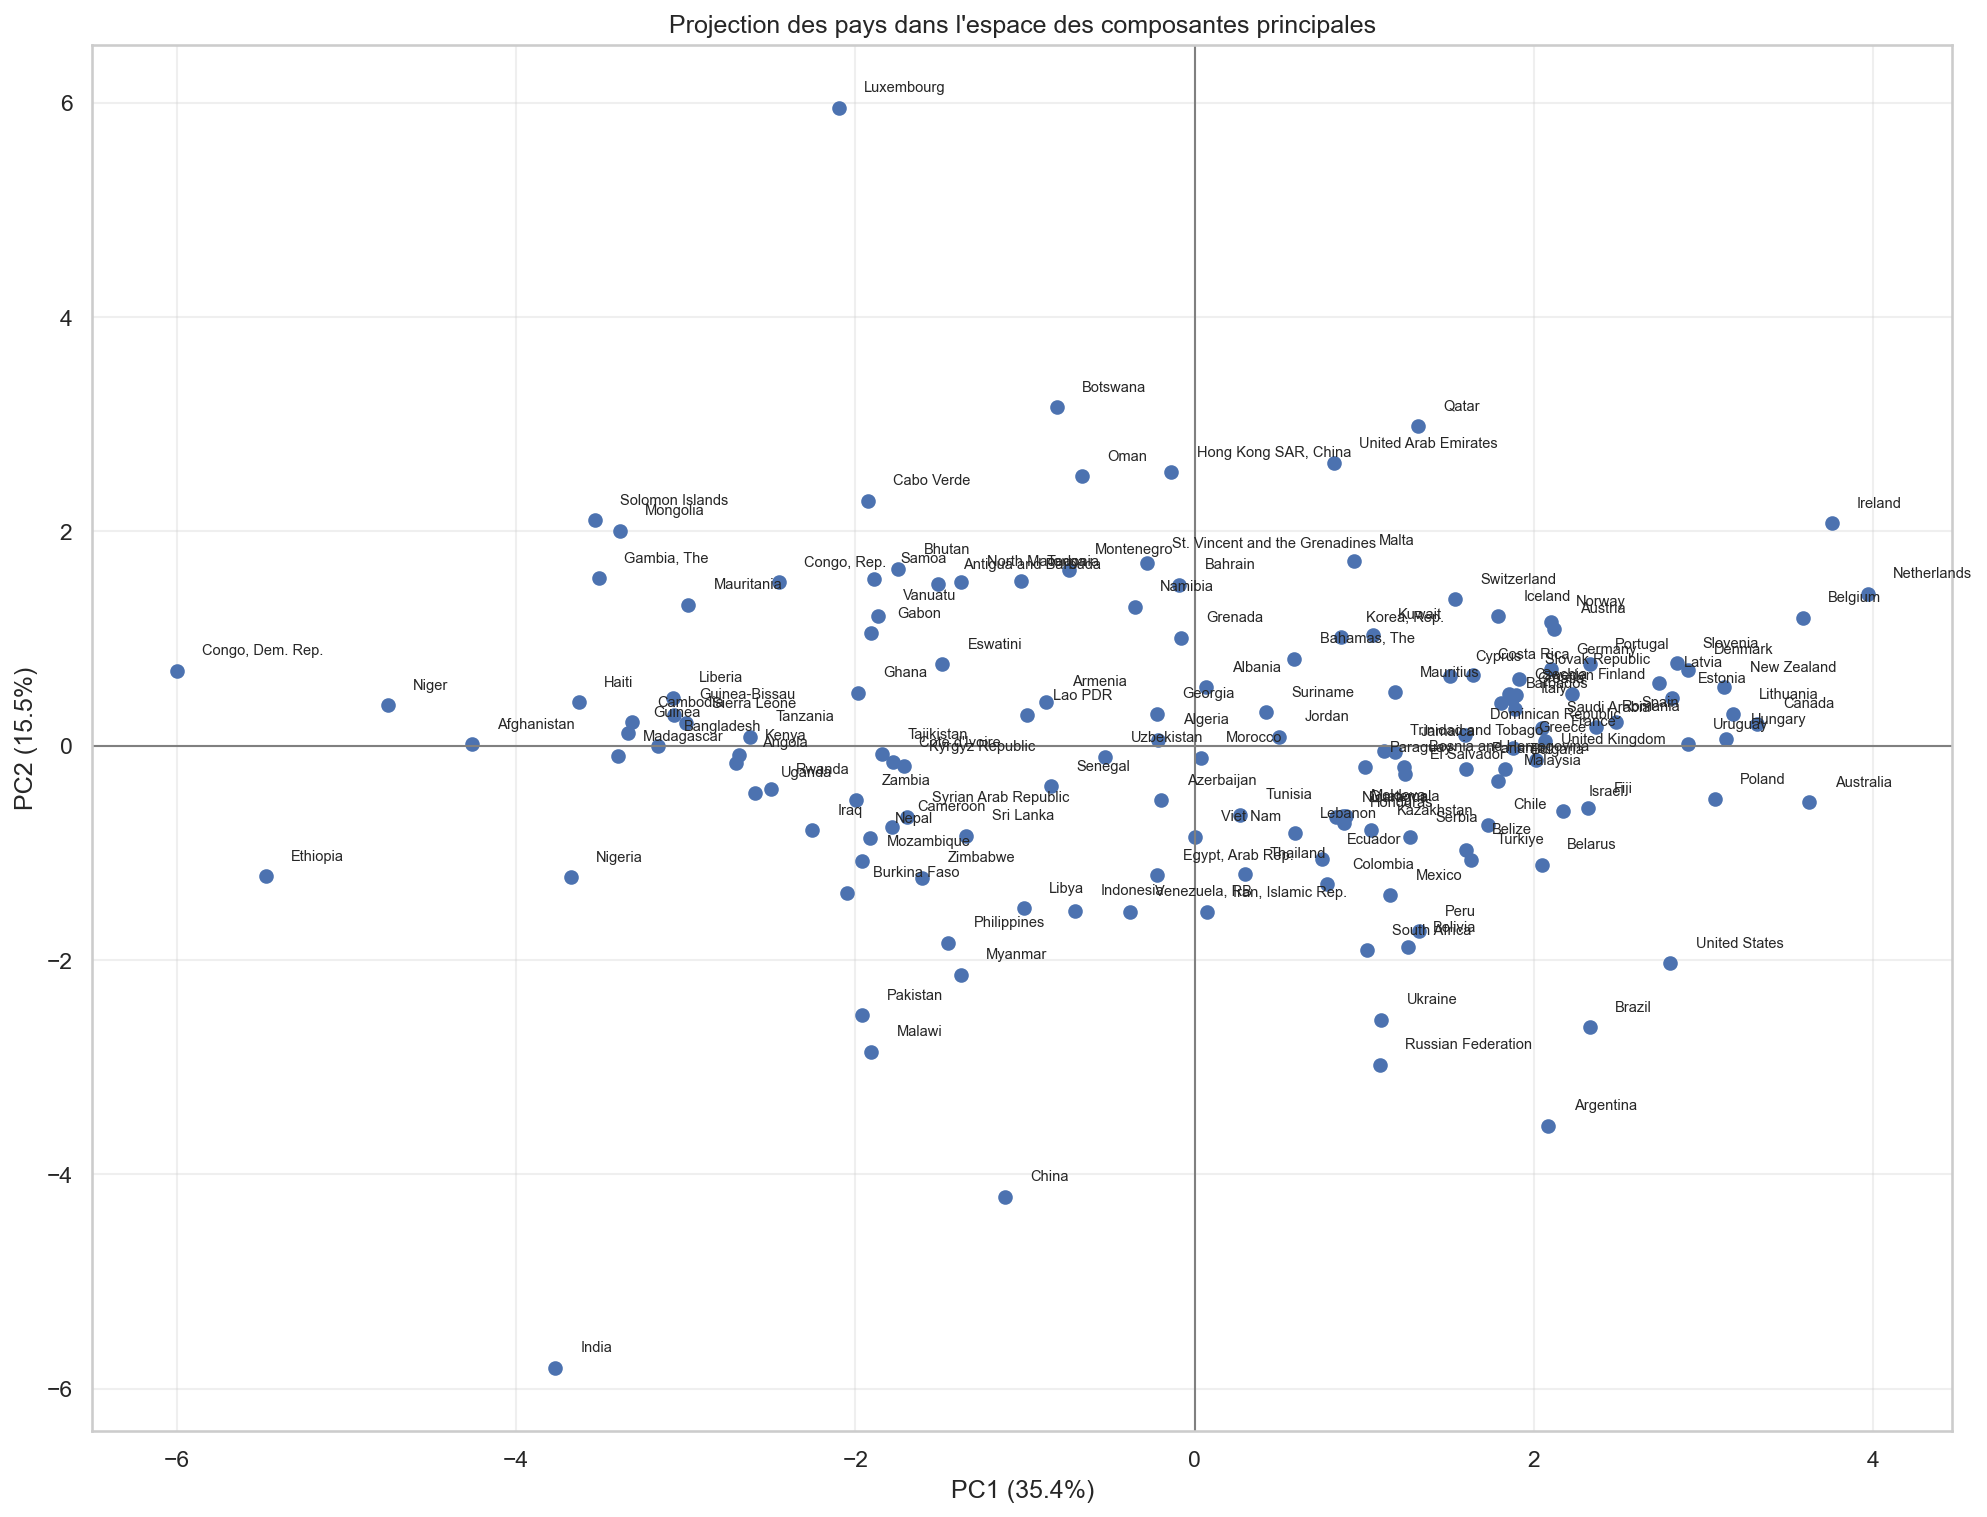

In [32]:
plt.figure(figsize=(16,12),dpi=150)
plt.scatter(donnees_acp["PC1"], donnees_acp["PC2"])

# Labels décalés
for i in range(donnees_acp.shape[0]):
    x = donnees_acp["PC1"].iloc[i]
    y = donnees_acp["PC2"].iloc[i]
    country = donnees_acp["Country"].iloc[i]
    plt.text(x + 0.15, y + 0.15, country, fontsize=7)
    
plt.axhline(0, color='grey', linewidth=1)
plt.axvline(0, color='grey', linewidth=1)

plt.xlabel("PC1 (%.1f%%)" % (pca.explained_variance_ratio_[0]*100))
plt.ylabel("PC2 (%.1f%%)" % (pca.explained_variance_ratio_[1]*100))
plt.title("Projection des pays dans l'espace des composantes principales")
plt.grid(alpha=0.3)
plt.show()

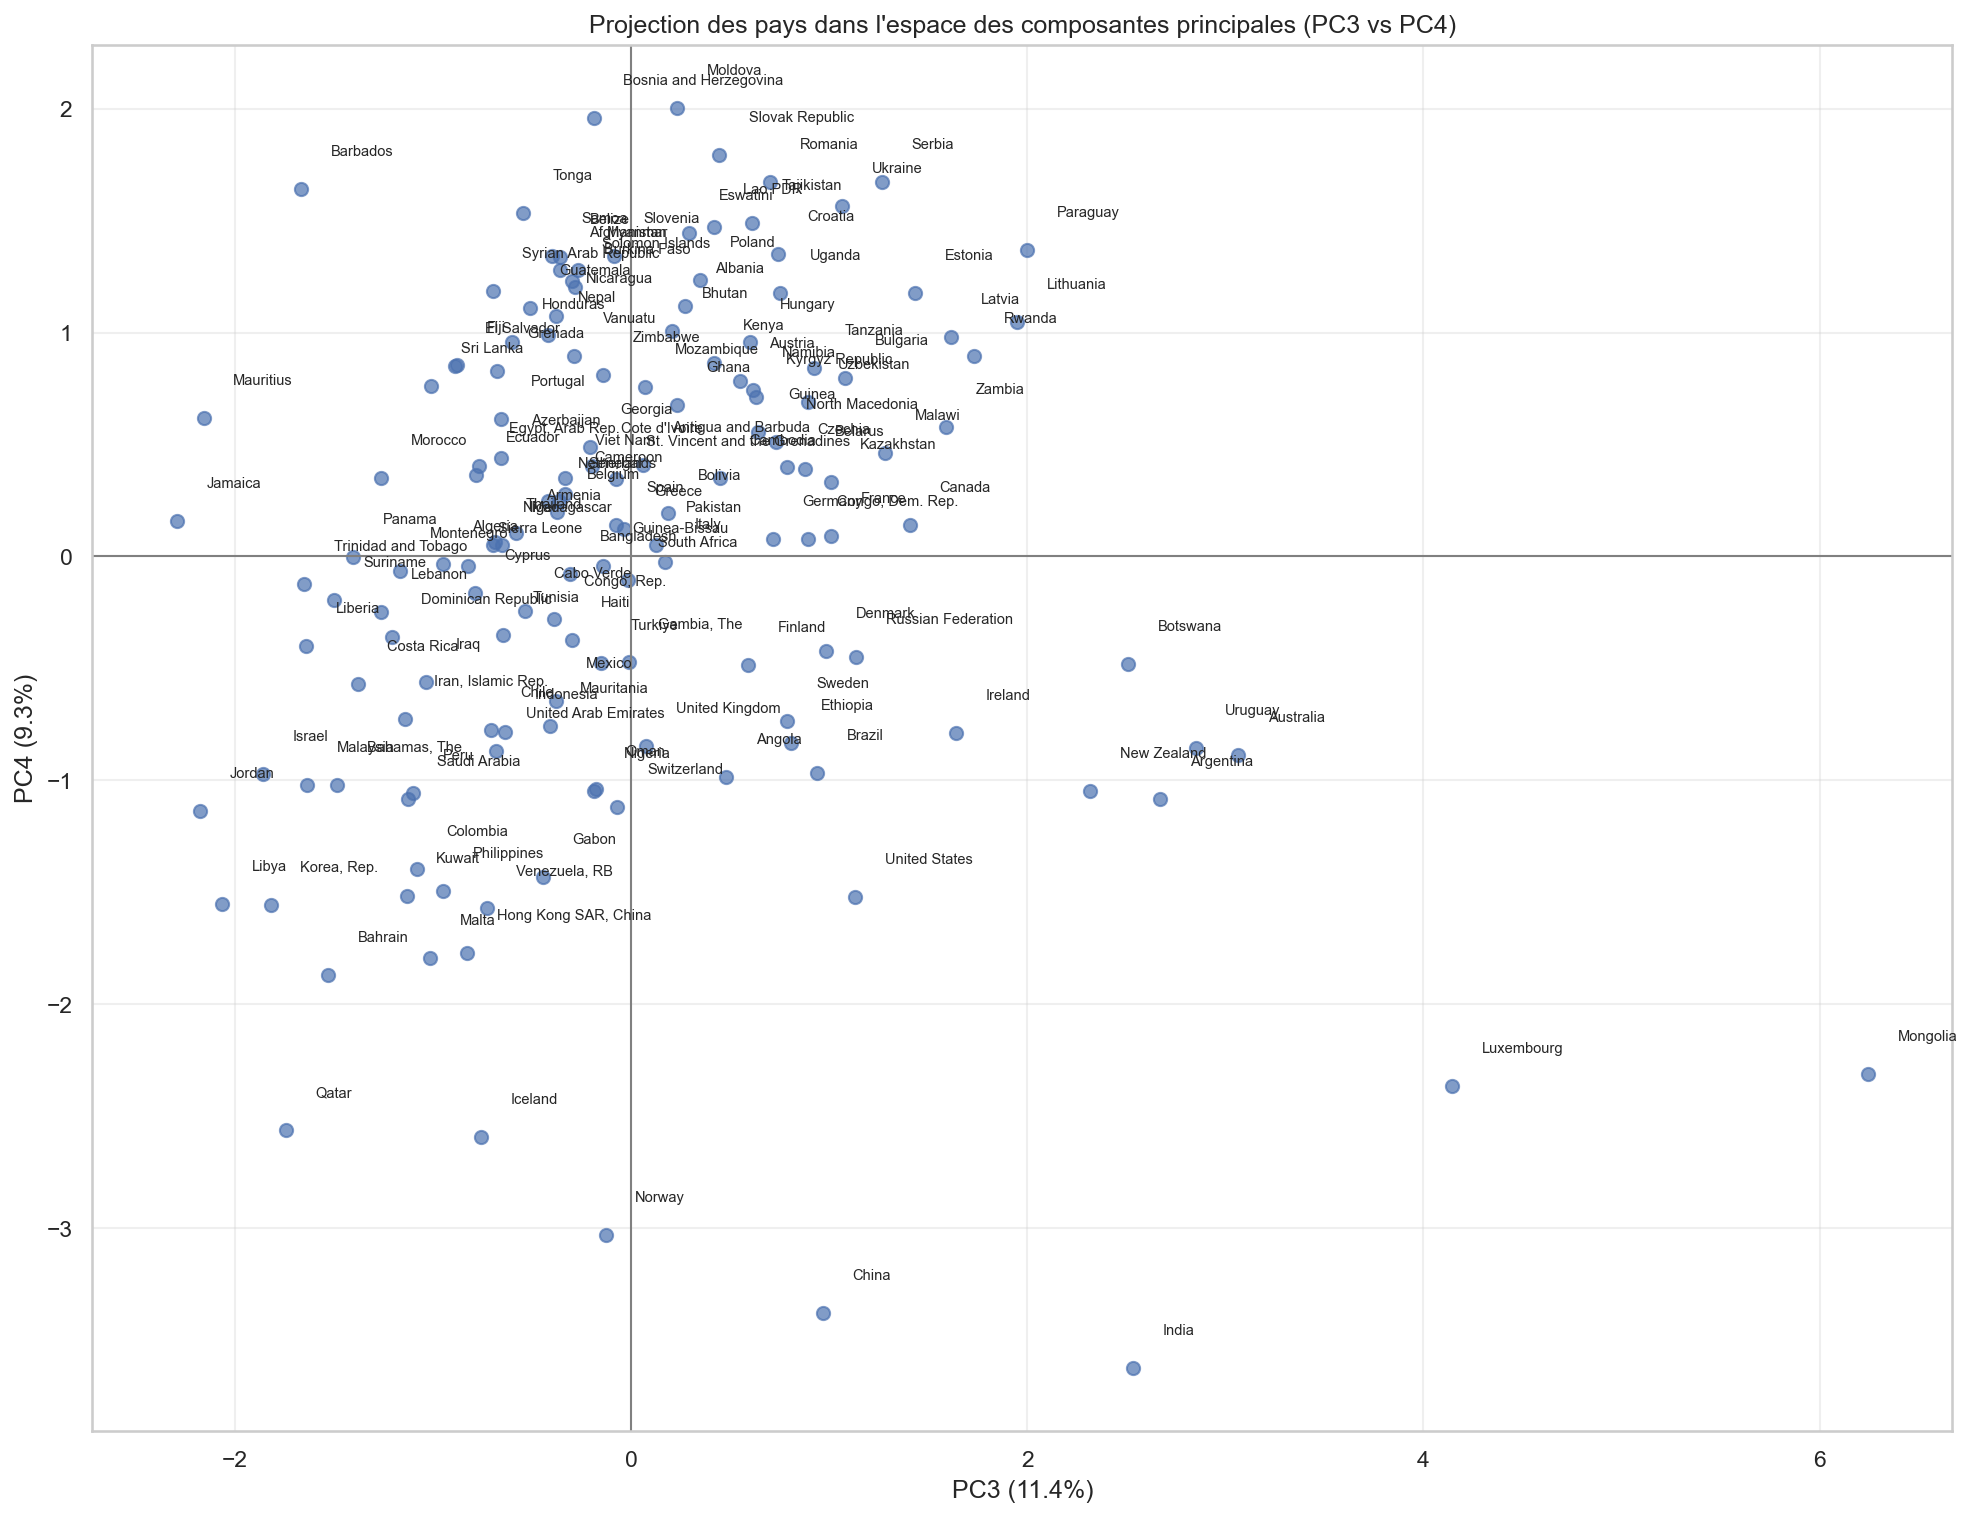

In [33]:
plt.figure(figsize=(16,12), dpi=150)

plt.scatter(donnees_acp["PC3"], donnees_acp["PC4"], s=40, alpha=0.7)

# Labels décalés
for i in range(donnees_acp.shape[0]):
    x = donnees_acp["PC3"].iloc[i]
    y = donnees_acp["PC4"].iloc[i]
    country = donnees_acp["Country"].iloc[i]
    plt.text(x + 0.15, y + 0.15, country, fontsize=7)

plt.axhline(0, color='grey', linewidth=1)
plt.axvline(0, color='grey', linewidth=1)

plt.xlabel("PC3 (%.1f%%)" % (pca.explained_variance_ratio_[2]*100))
plt.ylabel("PC4 (%.1f%%)" % (pca.explained_variance_ratio_[3]*100))
plt.title("Projection des pays dans l'espace des composantes principales (PC3 vs PC4)")
plt.grid(alpha=0.3)
plt.show()


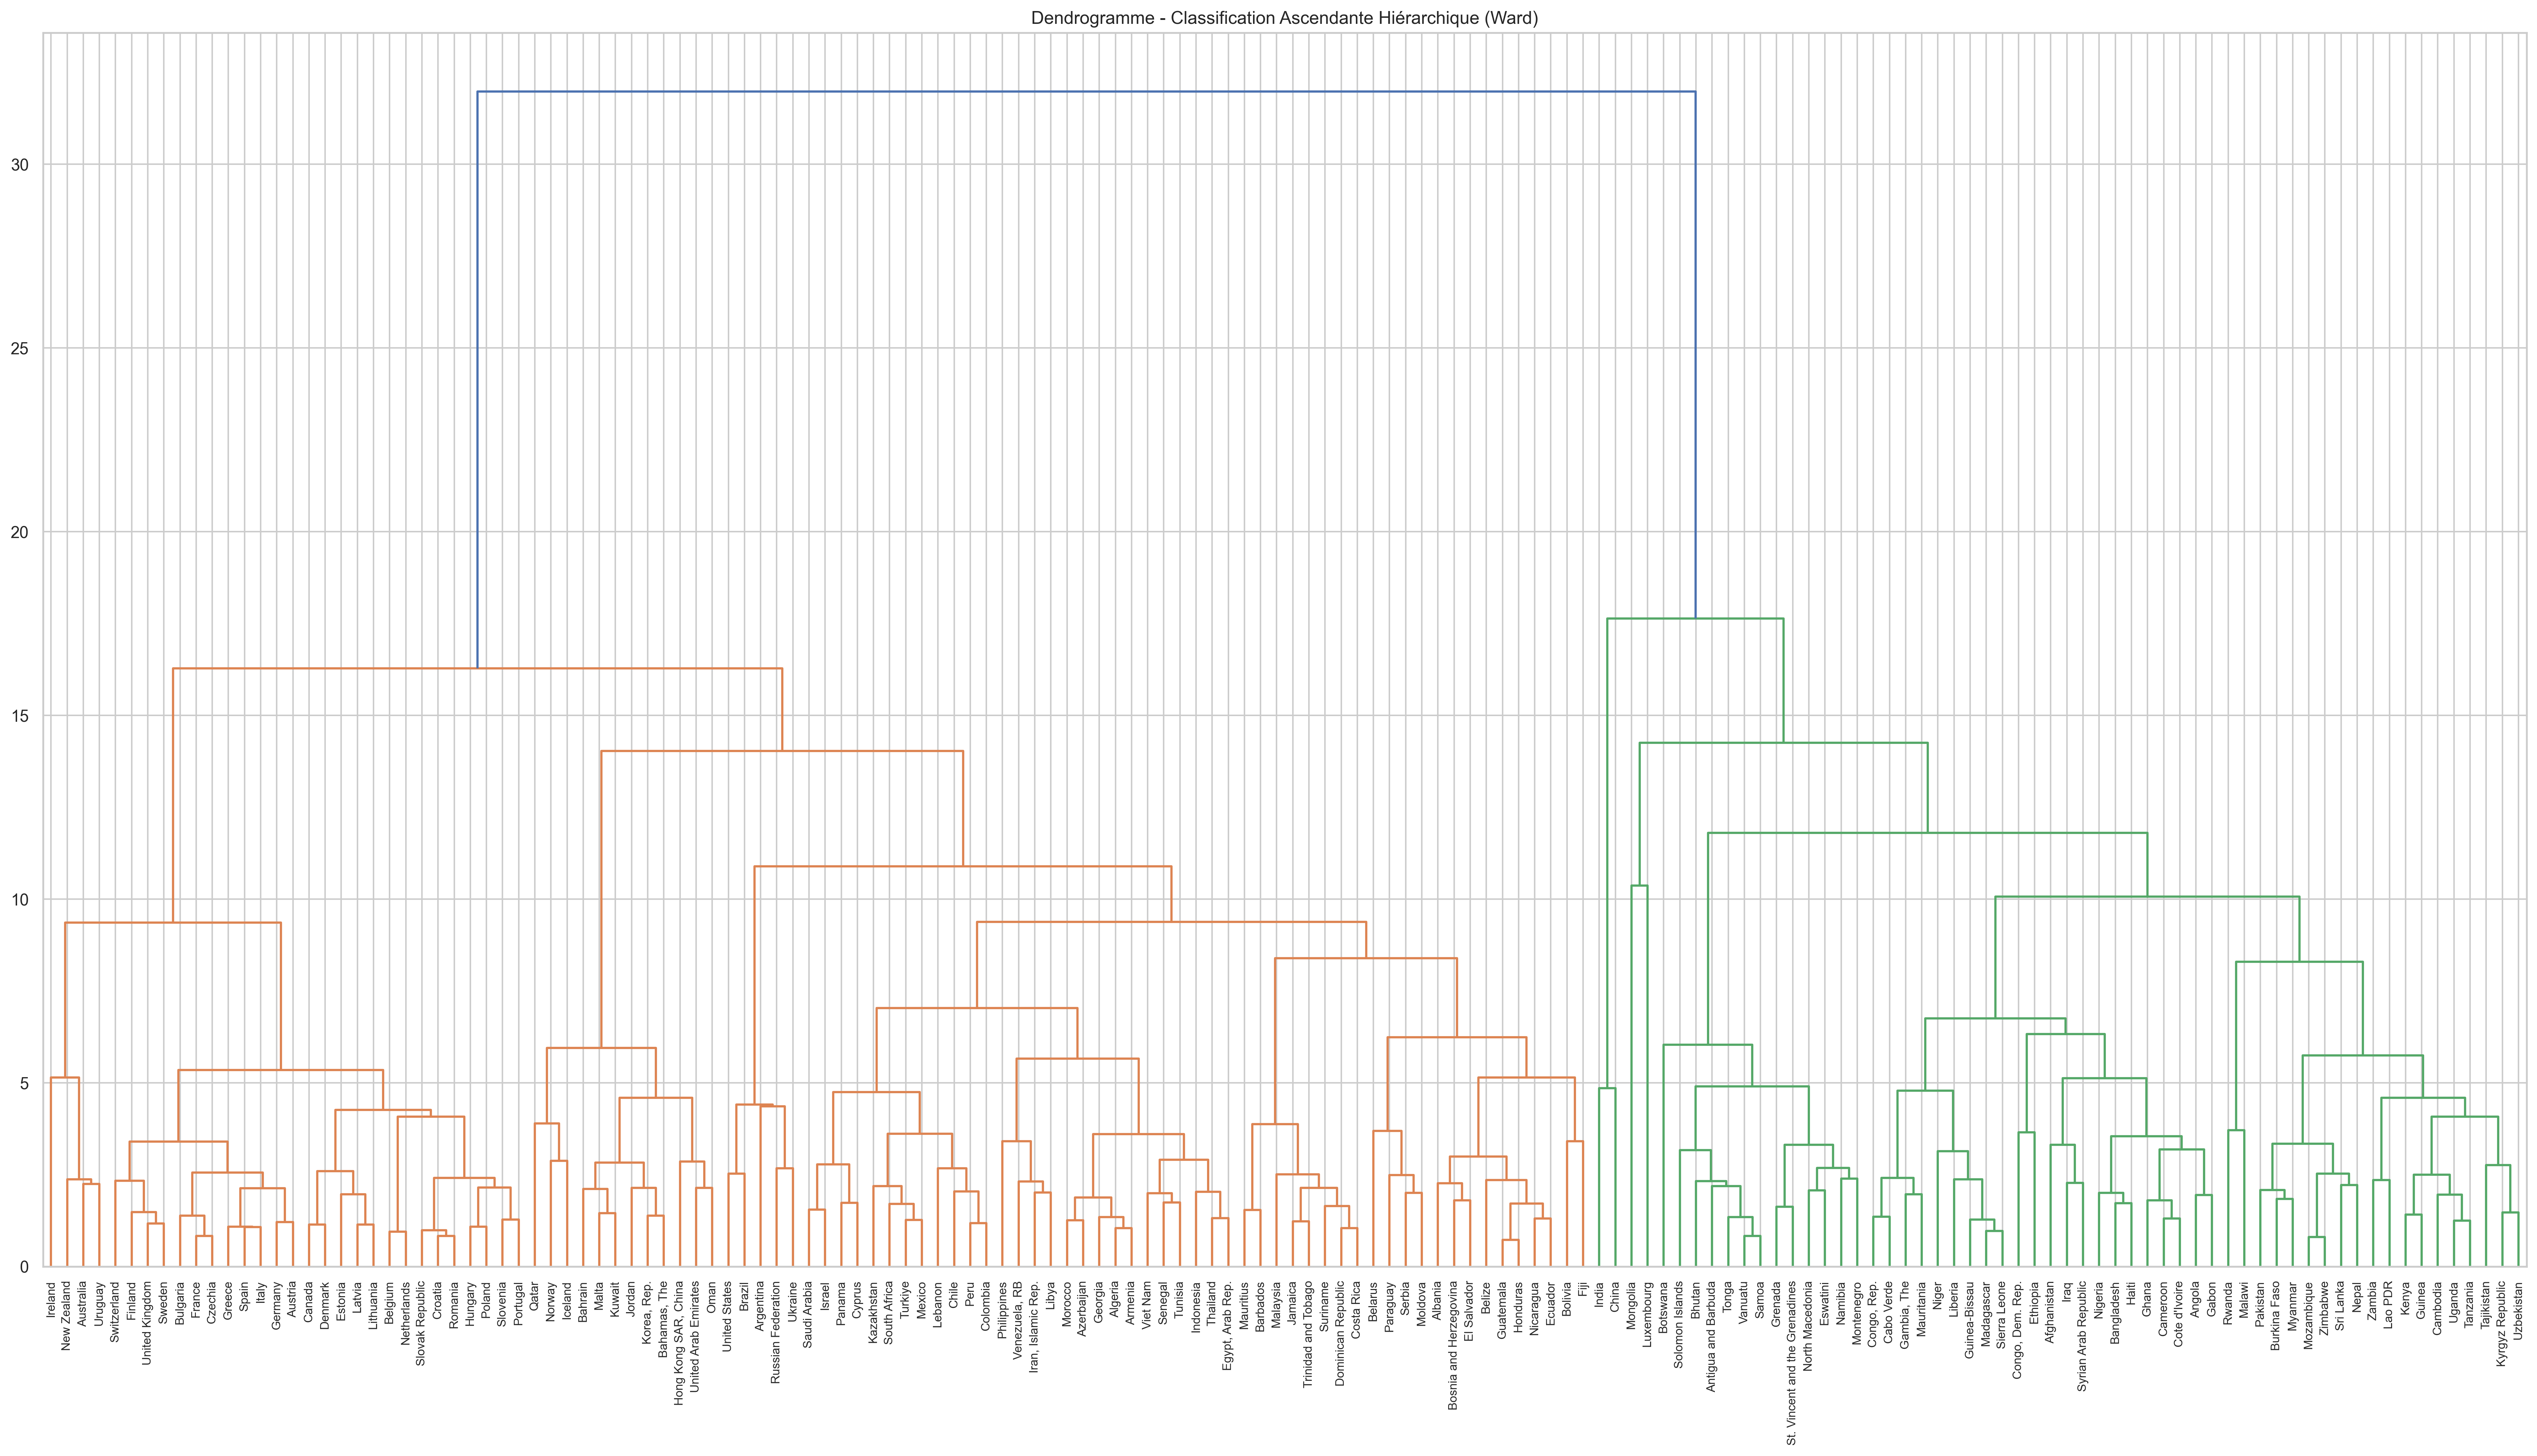

In [34]:
# CAH avec méthode Ward 
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(30, 15),dpi=300)
dendrogram(
    Z,
    labels=donnees_acp["Country"].values,
    leaf_rotation=90,
    leaf_font_size=8
)
plt.title("Dendrogramme - Classification Ascendante Hiérarchique (Ward)")
plt.show()

In [35]:
# Création du dendrogramme interactif
fig = ff.create_dendrogram(
    X_scaled,
    labels=donnees_acp["Country"].values,
    orientation='bottom',
    linkagefun=lambda x: linkage(x, method='ward')
)

# Taille du graphique
fig.update_layout(
    width=1400,
    height=800,
    title="Dendrogramme interactif - CAH (Ward)",
    xaxis=dict(tickfont=dict(size=10)),
)

fig.show()

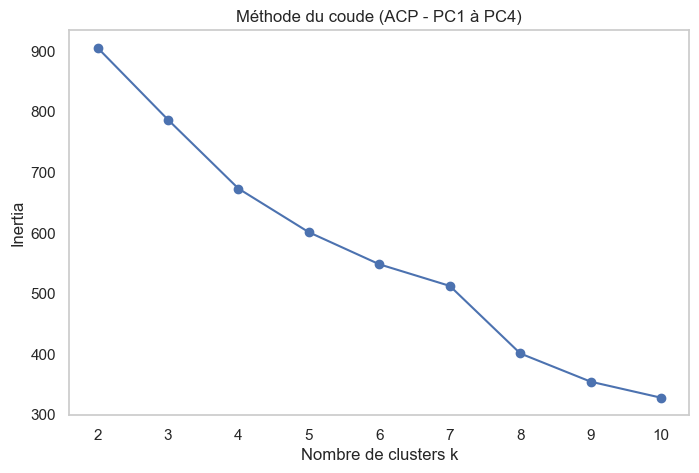

In [36]:
X_kmeans = donnees_acp[["PC1", "PC2", "PC3", "PC4"]].values

inertia = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X_kmeans)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.xlabel("Nombre de clusters k")
plt.ylabel("Inertia")
plt.title("Méthode du coude (ACP - PC1 à PC4)")
plt.grid()
plt.show()


In [37]:
k = 7
kmeans = KMeans(n_clusters=k, random_state=0)
donnees_acp["cluster"] = kmeans.fit_predict(X_kmeans)

In [38]:
donnees_acp.head()
donnees_acp["cluster_str"]=donnees_acp["cluster"].astype(str)
donnees_acp.head()

,Country,taux_remplissage,nb_colonnes_remplies,ISO3,indicateur_perf_logistique,pib_par_hab,stab_politique,population,tx_urbanisation,tarif_douanier_moyen,...,poultry_import_t,cereal_production_t,cereal_import_t,cereal_export_t,PC1,PC2,PC3,PC4,cluster,cluster_str
0,Belgium,100.0,26,BEL,4.0,68157.834786,0.581982,11680210.0,98.153,1.95,...,109384.0,2352.0,9771.0,3460.0,3.582773,1.190815,-0.372074,0.199128,1,1
1,Chile,100.0,26,CHL,3.0,30820.352697,0.132084,19553036.0,87.912,1.03,...,448.0,1715.0,4077.0,70.0,1.729480,-0.738345,-0.708505,-0.776758,1,1
2,Canada,100.0,26,CAN,4.0,63578.320195,0.780682,38935934.0,81.752,1.83,...,31890.0,48895.0,8213.0,22936.0,3.315496,0.205325,1.406502,0.141053,1,1
3,Bosnia and Herzegovina,100.0,26,BIH,3.0,21117.283077,-0.483194,3204802.0,49.841,3.39,...,29708.0,1268.0,773.0,100.0,1.232864,-0.197694,-0.188829,1.958464,1,1
4,Switzerland,100.0,26,CHE,4.1,91326.131705,1.159745,8777088.0,74.092,3.16,...,309.0,612.0,1606.0,184.0,1.532440,1.365408,-0.069983,-1.118441,6,6


In [39]:
usa=donnees_acp[donnees_acp['Country']=="United States"]
usa

,Country,taux_remplissage,nb_colonnes_remplies,ISO3,indicateur_perf_logistique,pib_par_hab,stab_politique,population,tx_urbanisation,tarif_douanier_moyen,...,poultry_import_t,cereal_production_t,cereal_import_t,cereal_export_t,PC1,PC2,PC3,PC4,cluster,cluster_str
5,United States,100.0,26,USA,3.8,77860.911291,0.008701,334017321.0,83.084,2.72,...,4021.0,391746.0,12603.0,83289.0,2.802083,-2.031979,1.129954,-1.520049,2,2


In [40]:
fig = px.scatter(
    donnees_acp,
    x="PC1",
    y="PC2",
    color="cluster_str",
    hover_name="Country",
    hover_data={"PC1":":.2f", "PC2":":.2f"},
    title="Clustering des pays (ACP + K-means) – Graphique interactif"
)

# Ajout des lignes verticales/horizontales
fig.add_shape(type="line", x0=0, y0=donnees_acp["PC2"].min(),
              x1=0, y1=donnees_acp["PC2"].max(),
              line=dict(color="grey", width=1))

fig.add_shape(type="line", x0=donnees_acp["PC1"].min(), y0=0,
              x1=donnees_acp["PC1"].max(), y1=0,
              line=dict(color="grey", width=1))

fig.update_layout(
    width=900,
    height=700,
    xaxis_title=f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)",
    yaxis_title=f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)",
)

fig.show()

In [41]:
fig = px.scatter(
    donnees_acp,
    x="PC3",
    y="PC4",
    color="cluster_str",
    hover_name="Country",
    hover_data={"PC3":":.2f", "PC4":":.2f"},
    title="Clustering des pays (ACP + K-means) – Plan PC3–PC4"
)

# Lignes verticales et horizontales
fig.add_shape(type="line", 
              x0=0, y0=donnees_acp["PC4"].min(),
              x1=0, y1=donnees_acp["PC4"].max(),
              line=dict(color="grey", width=1))

fig.add_shape(type="line",
              x0=donnees_acp["PC3"].min(), y0=0,
              x1=donnees_acp["PC3"].max(), y1=0,
              line=dict(color="grey", width=1))

fig.update_layout(
    width=900,
    height=700,
    xaxis_title=f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)",
    yaxis_title=f"PC4 ({pca.explained_variance_ratio_[3]*100:.1f}%)",
)

fig.show()

In [42]:
donnees_acp["cluster"].value_counts()

cluster
1    43
4    34
0    26
3    23
6    13
2    13
5     2
Name: count, dtype: int64

In [43]:
donnees_originales = df_acp.copy()   # ou le nom de ton dataset initial
donnees_originales["cluster"] = donnees_acp["cluster"]


In [44]:
caract_vars = donnees_originales.groupby("cluster").mean(numeric_only=True)
caract_vars


,pib_par_hab,stab_politique,population,tx_urbanisation,emissions_agri_pc,livestock_yield_carcass_weight,cereal_production_t_per_capita,livestock_production_per_capita,Producing Animals/Slaughtered_per_capita,food_balance_production_per_capita,cereal_import_t_per_capita,cereal_export_t_per_capita,poultry_import_t_per_capita
cluster,,,,,,,,,,,,,
0,5320.148695,-0.766253,4.237545e+07,44.178154,374.022218,1103.538462,-10.697915,-6.849097,-6.863823,-13.540405,-10.518760,-14.772411,-11.317808
1,46783.858752,0.436079,1.632358e+07,71.425512,445.538748,1711.930233,-8.727509,-3.622927,-4.102723,-10.462862,-8.493353,-9.179805,-7.140190
2,33373.384140,-0.402766,8.628722e+07,78.923846,798.946015,2100.000000,-7.448113,-3.293829,-4.010315,-10.179439,-10.269206,-8.930371,-10.641225
3,13562.602295,0.309461,6.519288e+06,47.481870,297.416249,1098.434783,-10.415418,-6.065775,-6.093765,-12.383374,-9.082094,-11.744929,-8.712230
4,12715.818009,-0.731815,4.541987e+07,56.067500,191.693764,1517.441176,-10.089158,-4.175047,-4.539692,-11.036701,-9.370451,-12.700256,-10.883720
5,16119.652029,-0.533152,1.418799e+09,49.716000,175.782475,1467.500000,-8.674901,-5.099231,-5.473746,-11.742472,-12.935785,-12.804469,-14.491021
6,77264.152374,0.726762,7.599501e+06,89.829000,181.068410,1224.230769,-12.354524,-5.410295,-5.555868,-11.698479,-8.277801,-11.177085,-10.531362


In [45]:
scaler = StandardScaler()
scaled = scaler.fit_transform(df_acp)  # df_acp = variables utilisées dans le PCA
scaled_df = pd.DataFrame(scaled, columns=df_acp.columns)
scaled_df["cluster"] = donnees_acp["cluster"]

caract_std = scaled_df.groupby("cluster").mean()
caract_std

,pib_par_hab,stab_politique,population,tx_urbanisation,emissions_agri_pc,livestock_yield_carcass_weight,cereal_production_t_per_capita,livestock_production_per_capita,Producing Animals/Slaughtered_per_capita,food_balance_production_per_capita,cereal_import_t_per_capita,cereal_export_t_per_capita,poultry_import_t_per_capita
cluster,,,,,,,,,,,,,
0,-0.833489,-0.742587,-0.040383,-0.808184,0.030607,-0.644527,-0.432640,-1.293233,-1.252307,-1.550528,-0.893749,-1.257378,-0.646469
1,0.667604,0.602607,-0.197651,0.444069,0.179319,0.446144,0.527860,0.739521,0.702955,0.780100,0.599237,0.877785,0.911251
2,0.182110,-0.335910,0.224699,0.788683,0.914193,1.141841,1.151518,0.946880,0.768394,0.994737,-0.709796,0.973014,-0.394190
3,-0.535091,0.460945,-0.256836,-0.656350,-0.128687,-0.653677,-0.294933,-0.799675,-0.706994,-0.674307,0.165258,-0.101537,0.325080
4,-0.565747,-0.704057,-0.022005,-0.261765,-0.348526,0.097481,-0.135893,0.391640,0.393518,0.345531,-0.047297,-0.466264,-0.484609
5,-0.442520,-0.481789,8.268686,-0.553672,-0.381612,0.007951,0.553504,-0.190673,-0.267930,-0.188950,-2.675408,-0.506051,-1.829674
6,1.771069,0.927829,-0.250316,1.289870,-0.370621,-0.428161,-1.240174,-0.386668,-0.326084,-0.155634,0.758126,0.115257,-0.353225


In [46]:
caract_pca = donnees_acp.groupby("cluster")[["PC1","PC2","PC3","PC4"]].mean()
caract_pca

,PC1,PC2,PC3,PC4
cluster,,,,
0,-3.261499,0.186584,0.295729,-0.024005
1,2.200852,0.222732,0.178969,0.408637
2,1.851080,-1.724132,1.106164,-0.346943
3,-1.192455,1.036572,0.104723,0.658950
4,-0.281829,-0.949310,-0.836704,0.073416
5,-2.444334,-5.007493,1.750763,-3.499396
6,0.615049,2.033495,-0.555923,-1.776171


In [47]:
import scipy.stats as stats

anova_results = []

for col in df_acp.columns:
    groups = [df_acp[col][donnees_acp["cluster"] == k] for k in sorted(donnees_acp.cluster.unique())]
    f, p = stats.f_oneway(*groups)
    anova_results.append({"Variable": col, "F": f, "p_value": p})

df_anova = pd.DataFrame(anova_results).sort_values("F", ascending=False)
df_anova


,Variable,F,p_value
2,population,276.596646,1.973377e-77
9,food_balance_production_per_capita,75.959109,1.470641e-42
7,livestock_production_per_capita,46.148909,1.904714e-31
0,pib_par_hab,40.883887,5.185966e-29
11,cereal_export_t_per_capita,39.296942,3.064617e-28
8,Producing Animals/Slaughtered_per_capita,32.654807,8.549425e-25
3,tx_urbanisation,19.386397,1.401501e-16
12,poultry_import_t_per_capita,19.030436,2.499243e-16
10,cereal_import_t_per_capita,18.012797,1.338313e-15
1,stab_politique,17.805318,1.892759e-15


Radar Chart

In [48]:

# caract_std = moyenne des clusters sur variables standardisées
# obtenu dans l'étape précédente
df_radar = caract_std.copy()

# ✅ Exclure population du radar
df_radar = df_radar.drop(columns=["population"], errors="ignore")

df_radar["cluster"] = df_radar.index

# Convertir en format long
df_long = df_radar.melt(
    id_vars="cluster",
    var_name="Variable",
    value_name="Valeur"
)

# Radar plot
fig = px.line_polar(
    df_long,
    r="Valeur",
    theta="Variable",
    color="cluster",
    line_close=True,
    markers=True,
    title="Radar plot – Profil standardisé des clusters (sans population)"
)

fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[df_long["Valeur"].min()-0.5, df_long["Valeur"].max()+0.5]
        )
    ),
    width=850,
    height=800
)

fig.show()



La variable "population" présente une dispersion structurellement très élevée entre pays.
Dans le radar des clusters, elle domine visuellement l’ensemble des autres indicateurs et
masque les différences de profils agricoles et commerciaux.
Afin de faciliter l’interprétation comparative des clusters, la population est exclue du radar
et analysée séparément.


In [49]:
df_pop = donnees_acp.copy()

fig = px.box(
    df_pop,
    x="cluster",
    y="population",
    points="all",                # montre les pays (utile)
    title="Population par cluster (échelle log)"
)

# échelle log pour éviter l’écrasement visuel
fig.update_yaxes(type="log", title="Population (log scale)")
fig.update_xaxes(title="Cluster")

fig.show()

Cluster 5 : très grands pays (médiane très élevée, peu d’observations)

Cluster 3 : petits pays (faible médiane)

Clusters 0 / 2 / 4 : pays intermédiaires

Cluster 6 : plutôt petits à moyens

Au regard des profils des clusters, le cluster 1 apparaît comme le marché le plus favorable
à l’exportation de poulet biologique. Il combine un niveau élevé d’importations de volaille
par habitant, un pouvoir d’achat important, une stabilité politique favorable et un fort taux
d’urbanisation. Ces caractéristiques sont particulièrement propices à la demande de produits
alimentaires différenciés à forte valeur ajoutée. Le cluster 6 constitue une alternative
intéressante pour des marchés premium, bien que plus concurrentiels et réglementés.


In [50]:
pays_cluster_2 = donnees_acp.loc[donnees_acp["cluster"] == 6, "Country"]

print("Pays du cluster 1 :")
for p in pays_cluster_2:
    print("-", p)


Pays du cluster 1 :
- Switzerland
- Korea, Rep.
- Norway
- Iceland
- Luxembourg
- United Arab Emirates
- Oman
- Malta
- Kuwait
- Bahamas, The
- Bahrain
- Hong Kong SAR, China
- Qatar


In [51]:
print(donnees_acp.columns)


Index(['Country', 'taux_remplissage', 'nb_colonnes_remplies', 'ISO3',
       'indicateur_perf_logistique', 'pib_par_hab', 'stab_politique',
       'population', 'tx_urbanisation', 'tarif_douanier_moyen',
       'emissions_agri_pc', 'organic_share', 'hfce_per_capita_usd_const2015',
       'food_balance_export_quantity', 'food_balance_import_quantity',
       'food_balance_production', 'Producing Animals/Slaughtered',
       'livestock_production', 'livestock_stock',
       'livestock_yield_carcass_weight', 'poultry_price_lcu_t',
       'poultry_export_t', 'poultry_import_t', 'cereal_production_t',
       'cereal_import_t', 'cereal_export_t', 'PC1', 'PC2', 'PC3', 'PC4',
       'cluster', 'cluster_str'],
      dtype='object')


In [52]:
df_c1 = donnees_acp[donnees_acp["cluster"] == 1]

df_c1["score_export"] = (
    df_c1["poultry_import_t"] +
    df_c1["pib_par_hab"] +
    df_c1["stab_politique"] +
    df_c1["tx_urbanisation"]
)

df_c1.sort_values("score_export", ascending=False).head(10)

,Country,taux_remplissage,nb_colonnes_remplies,ISO3,indicateur_perf_logistique,pib_par_hab,stab_politique,population,tx_urbanisation,tarif_douanier_moyen,...,cereal_production_t,cereal_import_t,cereal_export_t,PC1,PC2,PC3,PC4,cluster,cluster_str,score_export
35,Netherlands,100.0,26,NLD,4.1,77152.223761,0.726800,17700982.0,92.886,1.95,...,1340.0,18043.0,4979.0,3.965887,1.414787,-0.419997,0.249343,1,1,547778.836561
71,Germany,96.0,25,DEU,4.1,67589.839906,0.628492,83797985.0,77.648,1.95,...,26424.0,15041.0,13356.0,2.099504,0.712414,0.715042,0.078352,1,1,198863.116397
37,Poland,100.0,26,POL,3.6,46077.385556,0.505146,36821749.0,60.134,1.95,...,21540.0,5259.0,9740.0,3.065434,-0.500110,0.347647,1.236640,1,1,178465.024702
0,Belgium,100.0,26,BEL,4.0,68157.834786,0.581982,11680210.0,98.153,1.95,...,2352.0,9771.0,3460.0,3.582773,1.190815,-0.372074,0.199128,1,1,177640.569768
34,Romania,100.0,26,ROU,3.2,42217.920450,0.431136,19048502.0,54.489,1.95,...,16725.0,4310.0,11942.0,2.365700,0.175351,0.701253,1.673168,1,1,164133.840586
74,Ireland,96.0,25,IRL,3.6,136104.445332,0.884667,5212836.0,64.183,1.95,...,701.0,4731.0,919.0,3.752914,2.075056,1.641389,-0.789628,1,1,143355.513000
78,Spain,96.0,25,ESP,3.9,50468.096692,0.318843,47786102.0,81.304,1.95,...,10169.0,18715.0,2383.0,2.482729,0.220358,-0.075393,0.141196,1,1,102976.719536
124,Slovak Republic,88.0,23,SVK,3.3,41096.018502,0.445336,5431752.0,53.909,1.95,...,2732.0,1378.0,2791.0,1.911785,0.616827,0.445671,1.793233,1,1,98540.372838
2,Canada,100.0,26,CAN,4.0,63578.320195,0.780682,38935934.0,81.752,1.83,...,48895.0,8213.0,22936.0,3.315496,0.205325,1.406502,0.141053,1,1,95550.852877
121,Austria,88.0,23,AUT,4.0,70734.942565,0.648710,9041851.0,59.256,1.95,...,3827.0,3274.0,2278.0,2.120017,1.091982,0.547281,0.783526,1,1,89980.847275
